**LangGraph**

In [1]:
import os, sys
project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
if project_root not in sys.path:
    sys.path.append(project_root)
from agents.car.agent import car_graph as graph

**Test**

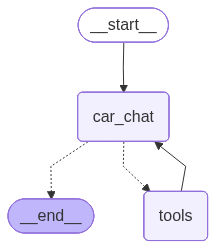

In [3]:
from IPython.display import Image, display

try:
    display(Image(graph.get_graph(xray=True).draw_mermaid_png()))
except Exception:
    pass

In [2]:
def stream_graph_updates(inputs: dict):
    for event in graph.stream(inputs):
        if "car_chat" in event:
            messages = event["car_chat"].get("messages", [])
            for msg in messages:
                # Nếu là AIMessage (object)
                if hasattr(msg, "content") and msg.content:
                    print("Assistant:", msg.content)
                # Nếu là dict
                elif isinstance(msg, dict) and msg.get("role") == "assistant":
                    print("Assistant:", msg.get("content"))
        if "tools" in event:
            messages = event["tools"].get("messages", [])
            for msg in messages:
                if hasattr(msg, "content") and msg.content:
                    print("Tool Output:", msg.content)
                elif isinstance(msg, dict):
                    print("Tool Output:", msg.get("content"))


In [ ]:
test_cases = [

    "Tìm kiếm một chỗ cho thuê xe tốt nhất ở Hà NộiNội."
]

for q in test_cases:
    print(f"\n🧑‍💻 User: {q}")
    inputs = {"messages": [{"role": "user", "content": q}]}
    print(inputs)
    stream_graph_updates(inputs)


🧑‍💻 User: Tìm kiếm một chỗ cho thuê xe ở Thủ đô Việt Nam.
{'messages': [{'role': 'user', 'content': 'Tìm kiếm một chỗ cho thuê xe ở Thủ đô Việt Nam.'}]}
Collection 'car_rentals' already exists. Skipping creation.
Collection 'car_details' already exists. Skipping creation.
Collection 'car_bookings' already exists. Skipping creation.
Found 21 existing car rentals points in Qdrant.
 Qdrant (Car Rentals) is up-to-date. No new car rentals to index.
Found 21 existing car details points in Qdrant.
 Qdrant (Car Details) is up-to-date. No new car details to index.
 Upserting 4 bookings (reflect updates)...
 Successfully upserted 4 bookings to Qdrant.
Qdrant semantic search: Found 0 results
Assistant: Tôi không tìm thấy địa điểm cho thuê xe nào ở Hà Nội. Bạn có muốn tôi tìm kiếm ở một thành phố khác không?


In [ ]:
test_cases = [
    # --- Test Cases for Searching ---
    # Test 1: Tìm kiếm với nhiều điều kiện
    "Tôi muốn tìm một chỗ cho thuê xe ở Hà Nội, thuộc phân khúc Economy và có rating cao .",
]

# --- Đoạn code chạy test (giữ nguyên) ---
for q in test_cases:
    print(f"==================================================")
    print(f"🧑‍💻 User: {q}")
    inputs = {"messages": [{"role": "user", "content": q}]}
    # Giả sử bạn có hàm stream_graph_updates để chạy graph
    stream_graph_updates(inputs)
    print(f"==================================================\n")


🧑‍💻 User: Tôi muốn tìm một chỗ cho thuê xe ở Hà Nội, thuộc phân khúc Economy và có rating cao .
Collection 'car_rentals' already exists. Skipping creation.
Collection 'car_details' already exists. Skipping creation.
Collection 'car_bookings' already exists. Skipping creation.
Found 21 existing car rentals points in Qdrant.
 Qdrant (Car Rentals) is up-to-date. No new car rentals to index.
Found 21 existing car details points in Qdrant.
 Qdrant (Car Details) is up-to-date. No new car details to index.
 Upserting 2 bookings (reflect updates)...
 Successfully upserted 2 bookings to Qdrant.
Qdrant semantic search: Found 2 results
Tool Output: [{"id": 3, "name": "EcoCar Service Hanoi", "location": "Hà Nội", "price_tier": "Economy", "rating": 8.2}, {"id": 1, "name": "Hanoi Drive Car Rental", "location": "Hà Nội", "price_tier": "Economy", "rating": 8.5}]
Assistant: Tuyệt vời! Tôi đã tìm thấy hai lựa chọn thuê xe ở Hà Nội thuộc phân khúc Economy với rating cao:

*   **Hanoi Drive Car Rental**: 

In [ ]:
test_cases = [

    "Tôi muốn kiếm xe có sức chứa 4 người ở Hanoi Drive Car Rental."
]

for q in test_cases:
    print(f"\n🧑‍💻 User: {q}")
    inputs = {"messages": [{"role": "user", "content": q}]}
    print(inputs)
    stream_graph_updates(inputs)


🧑‍💻 User: Tôi muốn kiếm xe có sức chứa 4 người ở Hanoi Drive Car Rental.
{'messages': [{'role': 'user', 'content': 'Tôi muốn kiếm xe có sức chứa 4 người ở Hanoi Drive Car Rental.'}]}
Resolved car_rental_name 'Hanoi Drive Car Rental' -> rental_id 1
Qdrant semantic search (cars): Found 2 results
Tool Output: [{"id": 2, "rental_id": 1, "car_name": "Hyundai Accent", "car_type": "Sedan 4 chỗ", "car_price": 750000, "car_capacity": 4}, {"id": 1, "rental_id": 1, "car_name": "Toyota Vios", "car_type": "Sedan 4 chỗ", "car_price": 700000, "car_capacity": 4}]
Assistant: Chúng tôi có hai xe có sức chứa 4 người ở Hanoi Drive Car Rental: Hyundai Accent và Toyota Vios.


In [ ]:
test_cases = [

    "Tôi muốn đặt xe tên Toyota Vios của Hanoi Drive Car Rental vào cho 4 người vào 22/12/2025 và kết thúc 23/12/2025."
]

for q in test_cases:
    print(f"\n🧑‍💻 User: {q}")
    inputs = {"messages": [{"role": "user", "content": q}]}
    print(inputs)
    stream_graph_updates(inputs)


🧑‍💻 User: Tôi muốn đặt xe tên Toyota Vios của Hanoi Drive Car Rental vào cho 4 người vào 22/12/2025 và kết thúc 23/12/2025.
{'messages': [{'role': 'user', 'content': 'Tôi muốn đặt xe tên Toyota Vios của Hanoi Drive Car Rental vào cho 4 người vào 22/12/2025 và kết thúc 23/12/2025.'}]}
Collection 'car_rentals' already exists. Skipping creation.
Collection 'car_details' already exists. Skipping creation.
Collection 'car_bookings' already exists. Skipping creation.
Found 21 existing car rentals points in Qdrant.
 Qdrant (Car Rentals) is up-to-date. No new car rentals to index.
Found 21 existing car details points in Qdrant.
 Qdrant (Car Details) is up-to-date. No new car details to index.
 Upserting 1 bookings (reflect updates)...
 Successfully upserted 1 bookings to Qdrant.
Collection 'car_rentals' already exists. Skipping creation.
Collection 'car_details' already exists. Skipping creation.
Collection 'car_bookings' already exists. Skipping creation.
Found 21 existing car rentals points

In [ ]:
test_cases = [

    "Tôi muốn cập nhập booking id 1 là đổi thành ngày 25/12/2025 đến 28/12/2025."
]

for q in test_cases:
    print(f"\n🧑‍💻 User: {q}")
    inputs = {"messages": [{"role": "user", "content": q}]}
    print(inputs)
    stream_graph_updates(inputs)


🧑‍💻 User: Tôi muốn cập nhập booking id 1 là đổi thành ngày 25/12/2025 đến 28/12/2025.
{'messages': [{'role': 'user', 'content': 'Tôi muốn cập nhập booking id 1 là đổi thành ngày 25/12/2025 đến 28/12/2025.'}]}
Using qrant: 
Tool Output: Không thể cập nhật mã đặt xe 1 vì đã bị hủy.
Assistant: Tôi không thể cập nhật mã đặt xe 1 vì nó đã bị hủy.


In [ ]:
test_cases = [

    "Tôi muốn hủy booking id 1."
]

for q in test_cases:
    print(f"\n🧑‍💻 User: {q}")
    inputs = {"messages": [{"role": "user", "content": q}]}
    print(inputs)
    stream_graph_updates(inputs)


🧑‍💻 User: Tôi muốn hủy booking id 1.
{'messages': [{'role': 'user', 'content': 'Tôi muốn hủy booking id 1.'}]}
Using qrant: 
Found 21 existing car rentals points in Qdrant.
 Qdrant (Car Rentals) is up-to-date. No new car rentals to index.
Found 21 existing car details points in Qdrant.
 Qdrant (Car Details) is up-to-date. No new car details to index.
 Upserting 2 bookings (reflect updates)...
 Successfully upserted 2 bookings to Qdrant.
Collection 'car_rentals' already exists. Skipping creation.
Collection 'car_details' already exists. Skipping creation.
Collection 'car_bookings' already exists. Skipping creation.
Found 21 existing car rentals points in Qdrant.
 Qdrant (Car Rentals) is up-to-date. No new car rentals to index.
Found 21 existing car details points in Qdrant.
 Qdrant (Car Details) is up-to-date. No new car details to index.
 Upserting 2 bookings (reflect updates)...
 Successfully upserted 2 bookings to Qdrant.
Tool Output: Đã hủy thành công mã đặt xe 1.
Assistant: Bạn đã

In [ ]:
test_cases = [

    "Tôi muốn đặt xe Hyundai của Hanoi Drive Car Rental cho 3 người vào 12/11/2025 đến 15/11/2025 ."
]

for q in test_cases:
    print(f"\n🧑‍💻 User: {q}")
    inputs = {"messages": [{"role": "user", "content": q}]}
    print(inputs)
    stream_graph_updates(inputs)


🧑‍💻 User: Tôi muốn đặt xe Hyundai của Hanoi Drive Car Rental cho 3 người vào 12/11/2025 đến 15/11/2025 .
{'messages': [{'role': 'user', 'content': 'Tôi muốn đặt xe Hyundai của Hanoi Drive Car Rental cho 3 người vào 12/11/2025 đến 15/11/2025 .'}]}
Collection 'car_rentals' already exists. Skipping creation.
Collection 'car_details' already exists. Skipping creation.
Collection 'car_bookings' already exists. Skipping creation.
Found 21 existing car rentals points in Qdrant.
 Qdrant (Car Rentals) is up-to-date. No new car rentals to index.
Found 21 existing car details points in Qdrant.
 Qdrant (Car Details) is up-to-date. No new car details to index.
 Qdrant (Bookings): No bookings to index.
Collection 'car_rentals' already exists. Skipping creation.
Collection 'car_details' already exists. Skipping creation.
Collection 'car_bookings' already exists. Skipping creation.
Found 21 existing car rentals points in Qdrant.
 Qdrant (Car Rentals) is up-to-date. No new car rentals to index.
Found 

In [ ]:
test_cases = [

    "Tôi muốn đặt xe m của Hanoi Drive Car Rental cho 3 người vào 12/11/2025 đến 15/11/2025 ."
]

for q in test_cases:
    print(f"\n🧑‍💻 User: {q}")
    inputs = {"messages": [{"role": "user", "content": q}]}
    print(inputs)
    stream_graph_updates(inputs)


🧑‍💻 User: Tôi muốn đặt xe m của Hanoi Drive Car Rental cho 3 người vào 12/11/2025 đến 15/11/2025 .
{'messages': [{'role': 'user', 'content': 'Tôi muốn đặt xe m của Hanoi Drive Car Rental cho 3 người vào 12/11/2025 đến 15/11/2025 .'}]}
Tool Output: Không tìm thấy xe 'xe m' tại đại lý 'Hanoi Drive Car Rental'.
Assistant: Tôi không tìm thấy xe 'xe m' tại Hanoi Drive Car Rental. Bạn có muốn thử tìm một loại xe khác không?


In [ ]:
test_cases = [

    "Tôi muốn đặt xe Vios của Hanoi Drive Car Rental cho 7 người vào 3/12/2025 đến 5/12/2025 ."
]

for q in test_cases:
    print(f"\n🧑‍💻 User: {q}")
    inputs = {"messages": [{"role": "user", "content": q}]}
    print(inputs)
    stream_graph_updates(inputs)


🧑‍💻 User: Tôi muốn đặt xe Vios của Hanoi Drive Car Rental cho 7 người vào 3/12/2025 đến 5/12/2025 .
{'messages': [{'role': 'user', 'content': 'Tôi muốn đặt xe Vios của Hanoi Drive Car Rental cho 7 người vào 3/12/2025 đến 5/12/2025 .'}]}
Tool Output: Xe chỉ có sức chứa 4 người. Không thể đặt cho 7 người.
Assistant: Tôi xin lỗi, xe Vios chỉ có sức chứa 4 người. Bạn có muốn đổi xe khác không?


**🚀 Test Hybrid Search với Qdrant**

Các test cases dưới đây sẽ demo khả năng semantic search của Qdrant:
- Tìm kiếm với từ đồng nghĩa
- Tìm kiếm với typo
- Tìm kiếm mơ hồ


In [ ]:
# Test 1: Semantic search với query mơ hồ
test_cases = [
    # Test với từ đồng nghĩa
    "Tôi muốn tìm chỗ thuê xe ở Thủ đô, đánh giá cao.",
    
    # # Test với typo (Ha Noi thay vì Hà Nội)
    # "Cho tôi xe ở Ha Noi, economy",
    
    # # Test với mô tả xe (semantic understanding)
    "Tôi cần xe sedan cao cấp ở  Hanoi Drive Car Rental",
]

print("=" * 80)
print("🧪 TESTING HYBRID SEARCH (Qdrant + Exact Filters)")
print("=" * 80)

for i, q in enumerate(test_cases, 1):
    print(f"\n{'='*80}")
    print(f"Test {i}: {q}")
    print(f"{'='*80}")
    inputs = {"messages": [{"role": "user", "content": q}]}
    stream_graph_updates(inputs)
    print()


🧪 TESTING HYBRID SEARCH (Qdrant + Exact Filters)

Test 1: Tôi muốn tìm chỗ thuê xe ở Thủ đô, đánh giá cao.
🔍 Qdrant semantic search: Found 21 results
Tool Output: [{"id": 2, "name": "VietCar Hanoi", "location": "Hà Nội", "price_tier": "Upper Midscale", "rating": 8.7}, {"id": 6, "name": "Saigon Budget Car", "location": "TP. Hồ Chí Minh", "price_tier": "Economy", "rating": 8.1}, {"id": 5, "name": "GoCar Saigon", "location": "TP. Hồ Chí Minh", "price_tier": "Luxury", "rating": 8.9}, {"id": 4, "name": "Saigon City Car Rental", "location": "TP. Hồ Chí Minh", "price_tier": "Upper Midscale", "rating": 8.8}, {"id": 1, "name": "Hanoi Drive Car Rental", "location": "Hà Nội", "price_tier": "Economy", "rating": 8.5}, {"id": 3, "name": "EcoCar Service Hanoi", "location": "Hà Nội", "price_tier": "Economy", "rating": 8.2}, {"id": 7, "name": "Danang Car Travel", "location": "Đà Nẵng", "price_tier": "Upper Midscale", "rating": 8.6}, {"id": 9, "name": "Central Car Service Danang", "location": "Đà Nẵng",

In [ ]:
test_cases = [

    "Tôi muốn đặt xe Toyota Vios của Hanoi Drive Car Rental cho 4 người vào 31/12/2025 đến 1/1/2026 ."
]

for q in test_cases:
    print(f"\n🧑‍💻 User: {q}")
    inputs = {"messages": [{"role": "user", "content": q}]}
    print(inputs)
    stream_graph_updates(inputs)


🧑‍💻 User: Tôi muốn đặt xe Toyota Vios của Hanoi Drive Car Rental cho 4 người vào 31/12/2025 đến 1/1/2026 .
{'messages': [{'role': 'user', 'content': 'Tôi muốn đặt xe Toyota Vios của Hanoi Drive Car Rental cho 4 người vào 31/12/2025 đến 1/1/2026 .'}]}
Collection 'car_rentals' already exists. Skipping creation.
Collection 'car_details' already exists. Skipping creation.
Collection 'car_bookings' already exists. Skipping creation.
Found 21 existing car rentals points in Qdrant.
 Qdrant (Car Rentals) is up-to-date. No new car rentals to index.
Found 21 existing car details points in Qdrant.
 Qdrant (Car Details) is up-to-date. No new car details to index.
 Upserting 2 bookings (reflect updates)...
 Successfully upserted 2 bookings to Qdrant.
Collection 'car_rentals' already exists. Skipping creation.
Collection 'car_details' already exists. Skipping creation.
Collection 'car_bookings' already exists. Skipping creation.
Found 21 existing car rentals points in Qdrant.
 Qdrant (Car Rentals) 

In [4]:
test_cases = [

    "Tôi muốn đặt xe toyota của Hanoi Drive Car Rental cho 4 người vào 31/12/2025 đến 1/1/2026 ."
]

for q in test_cases:
    print(f"\n🧑‍💻 User: {q}")
    inputs = {"messages": [{"role": "user", "content": q}]}
    print(inputs)
    stream_graph_updates(inputs)


🧑‍💻 User: Tôi muốn đặt xe toyota của Hanoi Drive Car Rental cho 4 người vào 31/12/2025 đến 1/1/2026 .
{'messages': [{'role': 'user', 'content': 'Tôi muốn đặt xe toyota của Hanoi Drive Car Rental cho 4 người vào 31/12/2025 đến 1/1/2026 .'}]}
Collection 'car_rentals' already exists. Skipping creation.
Collection 'car_details' already exists. Skipping creation.
Collection 'car_bookings' already exists. Skipping creation.
Found 21 existing car rentals points in Qdrant.
 Qdrant (Car Rentals) is up-to-date. No new car rentals to index.
Found 21 existing car details points in Qdrant.
 Qdrant (Car Details) is up-to-date. No new car details to index.
 Upserting 3 bookings (reflect updates)...
 Successfully upserted 3 bookings to Qdrant.
Tool Output: Xe 'Toyota' tại đại lý 'Hanoi Drive Car Rental' đã được đặt trong khoảng thời gian '31/12/2025' - '1/1/2026'.
Assistant: Xe 'Toyota' tại đại lý 'Hanoi Drive Car Rental' đã được đặt trong khoảng thời gian '31/12/2025' - '1/1/2026'.


In [6]:
test_cases = [

    "Tôi muốn đặt xe toyota của Hanoi Drive Car Rental cho 4 người vào 1/1/2026 đến 2/1/2026 ."
]

for q in test_cases:
    print(f"\n🧑‍💻 User: {q}")
    inputs = {"messages": [{"role": "user", "content": q}]}
    print(inputs)
    stream_graph_updates(inputs)


🧑‍💻 User: Tôi muốn đặt xe toyota của Hanoi Drive Car Rental cho 4 người vào 1/1/2026 đến 2/1/2026 .
{'messages': [{'role': 'user', 'content': 'Tôi muốn đặt xe toyota của Hanoi Drive Car Rental cho 4 người vào 1/1/2026 đến 2/1/2026 .'}]}
Collection 'car_rentals' already exists. Skipping creation.
Collection 'car_details' already exists. Skipping creation.
Collection 'car_bookings' already exists. Skipping creation.
Found 21 existing car rentals points in Qdrant.
 Qdrant (Car Rentals) is up-to-date. No new car rentals to index.
Found 21 existing car details points in Qdrant.
 Qdrant (Car Details) is up-to-date. No new car details to index.
 Upserting 3 bookings (reflect updates)...
 Successfully upserted 3 bookings to Qdrant.
Qdrant semantic search: Found 1 results
Tool Output: [{"id": 1, "name": "Hanoi Drive Car Rental", "location": "Hà Nội", "price_tier": "Economy", "rating": 8.5}]
Resolved car_rental_name 'Hanoi Drive Car Rental' -> rental_id 1
Qdrant semantic search (cars): Found 2 